In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 블러링, 이미지 흐리게

In [8]:
src = np.random.randint(0, 3, (5, 5))

np.random.seed(43)
H = 5
W = 5
mask = np.full((3,3), 1/9)
mask_H = 3
mask_W = 3

dst = np.zeros_like(src).astype(float)

for h in range(1, H-1):
    for w in range(1, W-1):
        roi = src[h-1 : h-1+mask_H , w-1 : w-1+mask_W]
        dst[h,w] = np.sum(roi * mask)

dst
        

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.77777778, 1.22222222, 1.55555556, 0.        ],
       [0.        , 1.        , 1.11111111, 1.11111111, 0.        ],
       [0.        , 0.77777778, 0.55555556, 0.44444444, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

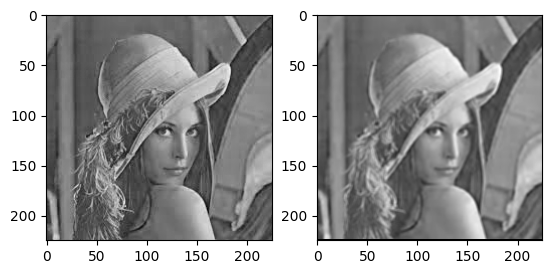

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src = cv2.imread("images/lenna.jpeg" )[:,:,0]

mask = np.full((3, 3), 1 / 9, dtype=np.float32)

H, W = src.shape[:2]
mask_H = mask.shape[0]
mask_W = mask.shape[1]

dst = np.zeros_like(src, dtype=np.float32)

for h in range(1, H - 1):
    for w in range(1, W - 1):
        roi = src[h - 1:h + 2, w - 1:w + 2]

        dst[h, w] = np.sum(
            roi * mask
        )

dst = np.clip(dst, 0, 255).astype(np.uint8)




plt.subplot(1, 2, 1)
plt.imshow(src, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(dst, cmap = 'gray')

plt.show()

# 선명하게

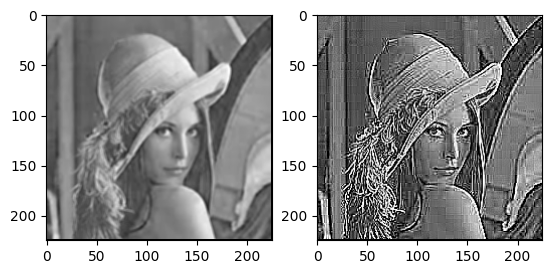

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src1 = dst

mask = np.array([[-1,-1,-1],
                  [-1,9,-1],
                  [-1,-1,-1]])

H, W = src.shape[:2]

dst = np.zeros_like(src, dtype=np.float32)

for h in range(1, H - 1):
    for w in range(1, W - 1):
        roi = src[h - 1:h + 2, w - 1:w + 2]

        dst[h, w] = np.sum(
            roi * mask
        )

dst = np.clip(dst, 0, 255).astype(np.uint8)


plt.subplot(1, 2, 1)
plt.imshow(src1, cmap = 'gray')



plt.subplot(1, 2, 2)
plt.imshow(dst, cmap = 'gray')
plt.show()

## CV2

cv2.filter2D

In [ ]:
# 기본 문법
# dst = cv2.filter2D(src, ddepth, kernel, anchor=None, delta=0, borderType=cv2.BORDER_DEFAULT)
# 주요 인자
# 인자	의미
# src	입력 이미지
# ddepth	출력 이미지의 깊이
# kernel	적용할 필터 커널
# anchor	커널의 기준점
# delta	결과에 추가할 값
# borderType	이미지 경계 처리 방식

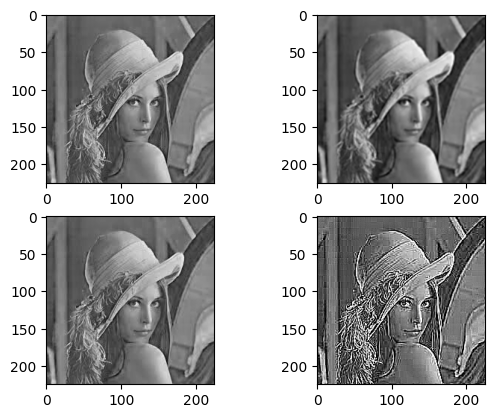

In [5]:
# 블러링
import cv2
import numpy as np
import matplotlib.pyplot as plt

src1 = cv2.imread("images/lenna.jpeg" )[:,:,0]

mask_b = np.full((3, 3), 1 / 9, dtype=np.float32)

dst1 = cv2.filter2D(src, -1, mask_b)

plt.subplot(2,2,1)
plt.imshow(src1, cmap = 'gray')
plt.subplot(2,2,2)
plt.imshow(dst1, cmap = 'gray')

# 샤프닝
src2 = cv2.imread("images/lenna.jpeg" )[:,:,0]

mask_s = np.array([[-1,-1,-1],
                  [-1,9,-1],
                  [-1,-1,-1]])

dst2 = cv2.filter2D(src, -1, mask_s)

plt.subplot(2,2,3)
plt.imshow(src2, cmap = 'gray')
plt.subplot(2,2,4)
plt.imshow(dst2, cmap = 'gray')

## 경계선 검출

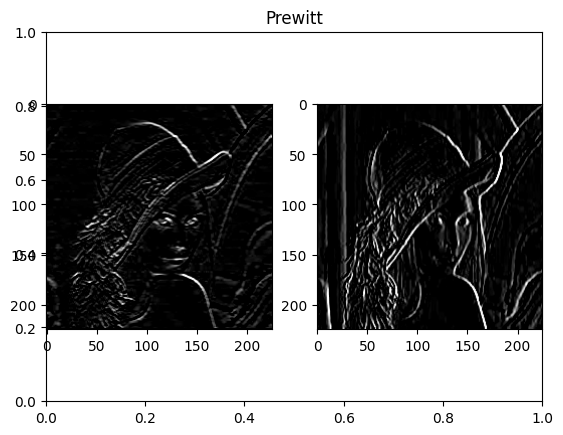

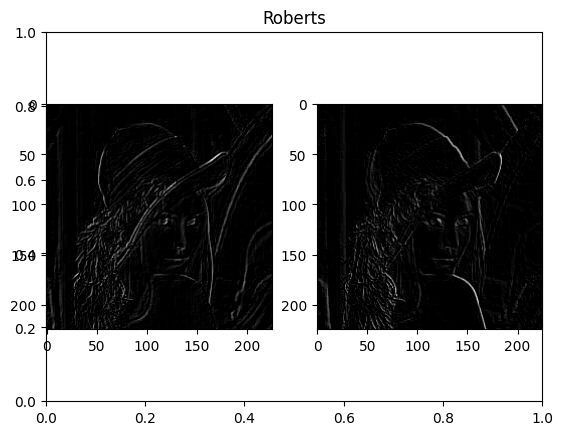

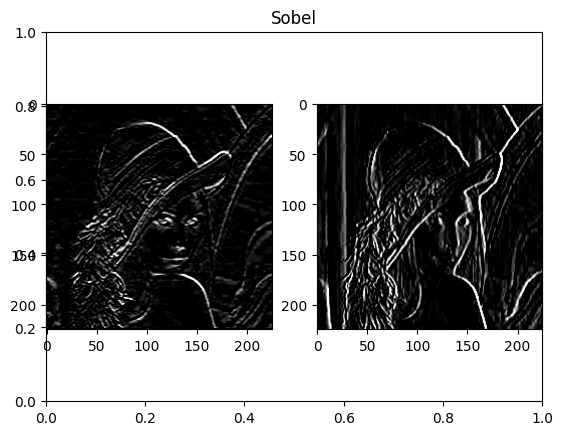

In [ ]:

src = cv2.imread("images/lenna.jpeg" )[:,:,0]

# Prewitt
Prewitt = {"H" : np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]), "V" : np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])}

dst_Prewitt_H = cv2.filter2D(src, -1, Prewitt["H"] )
dst_Prewitt_V = cv2.filter2D(src, -1, Prewitt["V"] )
dst_Prewitt = np.square(,dst_Prewitt_H**2 + dst_Prewitt_V**2)


# Roberts
Roberts = {"H" : np.array([[-1, 0, 0], [0, 1, 0], [0, 0, 0]]), "V" : np.array([[0, 0, -1], [0, 1, 0], [0, 0, 0]])}

dst_Roberts_H = cv2.filter2D(src, -1, Roberts["H"] )
dst_Roberts_V = cv2.filter2D(src, -1, Roberts["V"] )


# Sobel
Sobel = {"H" : np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]), "V" : np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])}

dst_Sovel_H = cv2.filter2D(src, -1, Sobel["H"] )
dst_Sovel_V = cv2.filter2D(src, -1, Sobel["V"] )


    


##########################################
plt.title("Prewitt")
plt.subplot(1,2,1)
plt.imshow(dst_Prewitt_H, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst_Prewitt_V, cmap = 'gray')
plt.show()
plt.title("Roberts")
plt.subplot(1,2,1)
plt.imshow(dst_Roberts_H, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst_Roberts_V, cmap = 'gray')
plt.show()
plt.title("Sobel")
plt.subplot(1,2,1)
plt.imshow(dst_Sovel_H, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst_Sovel_V, cmap = 'gray')
plt.show()

In [ ]:
##
size = 3

# eval 쓰면 string 을 실제 변수명으로 바꿔 줄 수 있음
# b_lst = [4, 5 ,6]
# split = 'b'
# lst_name = f"{split}_lst"
# eval(lst_name)

# def Filter(size, filter, axis) :
#     mask = np.full((size, size))

#     if filter == "prewitt" :
#         if axis == "H" :
#             mask[0, :] = -1
#             mask[-1 , :] = 1
#         elif axis == "W" :
#             mask[:, 0] = 1
#             mask[:, -1] = -1
    
#     if filter == "roberts":
#         mask[mask.shape[0]//2, mask.shape[1]//2] = 1
#         if axis == "H" :
            
        
mask = np.full((size, size))



##########################################
plt.title("Prewitt")
plt.subplot(1,2,1)
plt.imshow(dst_Prewitt_H, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst_Prewitt_V, cmap = 'gray')
plt.show()
plt.title("Roberts")
plt.subplot(1,2,1)
plt.imshow(dst_Roberts_H, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst_Roberts_V, cmap = 'gray')
plt.show()
plt.title("Sobel")
plt.subplot(1,2,1)
plt.imshow(dst_Sovel_H, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst_Sovel_V, cmap = 'gray')
plt.show()